# River Flood Exposure Analysis
## Workshop Notebook — Hazard Series (1 of 5)

This notebook overlays **river flood depth data** onto Serbia's main road network to identify which road segments are exposed to flooding.

**Key steps:**
1. Load the country boundary and road network
2. Load and clip the flood hazard raster to Serbia
3. Assign flood depth to each road segment
4. Correct flood depths for road elevation bias (roads sit above terrain)
5. Visualise results and save as ArcGIS layers

> **Note:** The elevation correction is critical — without it, flood depths are overestimated because flood maps measure depth relative to terrain, but roads are typically elevated above the surrounding ground.

## Step 1: Setup and Imports

In [43]:
import warnings
import sys
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray as rxr
import xarray as xr
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

### Load project utilities

We import helper functions from the project's `utils` module:
- `read_road_network` — reads road data from parquet/gpkg/shp
- `assign_flood_depth_to_roads` — overlays a flood raster onto road geometries
- `save_lyrx_layer` — saves results as GeoPackage + ArcGIS Pro layer file (.lyrx)

In [44]:
CODE_DIR = Path(r"C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\12_repositories\Criticality-Analysis-Roads-Serbia")
sys.path.append(str(CODE_DIR))
from utils.utils import read_road_network, assign_flood_depth_to_roads
from utils.arcgis import save_lyrx_layer

### Define file paths

All input data, intermediate results, and outputs are organised under a single project directory.

In [45]:
BASE_DIR = Path(r"C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2")

data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
intermediate_results_path = BASE_DIR / "intermediate_results"
arcgis_results = BASE_DIR / "results" / "ArcGIS layers"
arcgis_gpkg = arcgis_results / "Geopackages"

# Create output directories if they don't exist
figure_path.mkdir(parents=True, exist_ok=True)
arcgis_results.mkdir(parents=True, exist_ok=True)
arcgis_gpkg.mkdir(parents=True, exist_ok=True)

## Step 2: Load Data

### Country boundary and road network

In [47]:
# Load country outline
world_path = data_path / "ne_10m_admin_0_countries.shp"
world = gpd.read_file(world_path)
country_bounds = world.loc[world.SOV_A3 == 'SRB'].bounds
country_plot = world.loc[world.SOV_A3 == 'SRB']

# Load road network
roads = read_road_network(intermediate_results_path / "parquet" / "PERS_directed_final.parquet")
print(f"Road segments loaded: {len(roads):,}")

Road segments loaded: 5,490


### Load and clip the flood hazard raster

We use a **100-year return period** fluvial flood depth map and clip it to Serbia's bounding box.

In [48]:
fluvial_flooding_path = data_path / "Europe_RP100_filled_depth.tif"

hazard_map = xr.open_dataset(fluvial_flooding_path, engine="rasterio")
hazard_country = hazard_map.rio.clip_box(
    minx=country_bounds.minx.values[0],
    miny=country_bounds.miny.values[0],
    maxx=country_bounds.maxx.values[0],
    maxy=country_bounds.maxy.values[0]
).load()

print(f"Raster shape: {hazard_country.band_data.shape}")
print(f"Raster CRS: {hazard_country.rio.crs}")

Raster shape: (1, 4728, 4968)
Raster CRS: EPSG:4326


## Step 3: Visualise the Flood Hazard Map

Before overlaying on roads, let's look at the raw flood depth across Serbia.

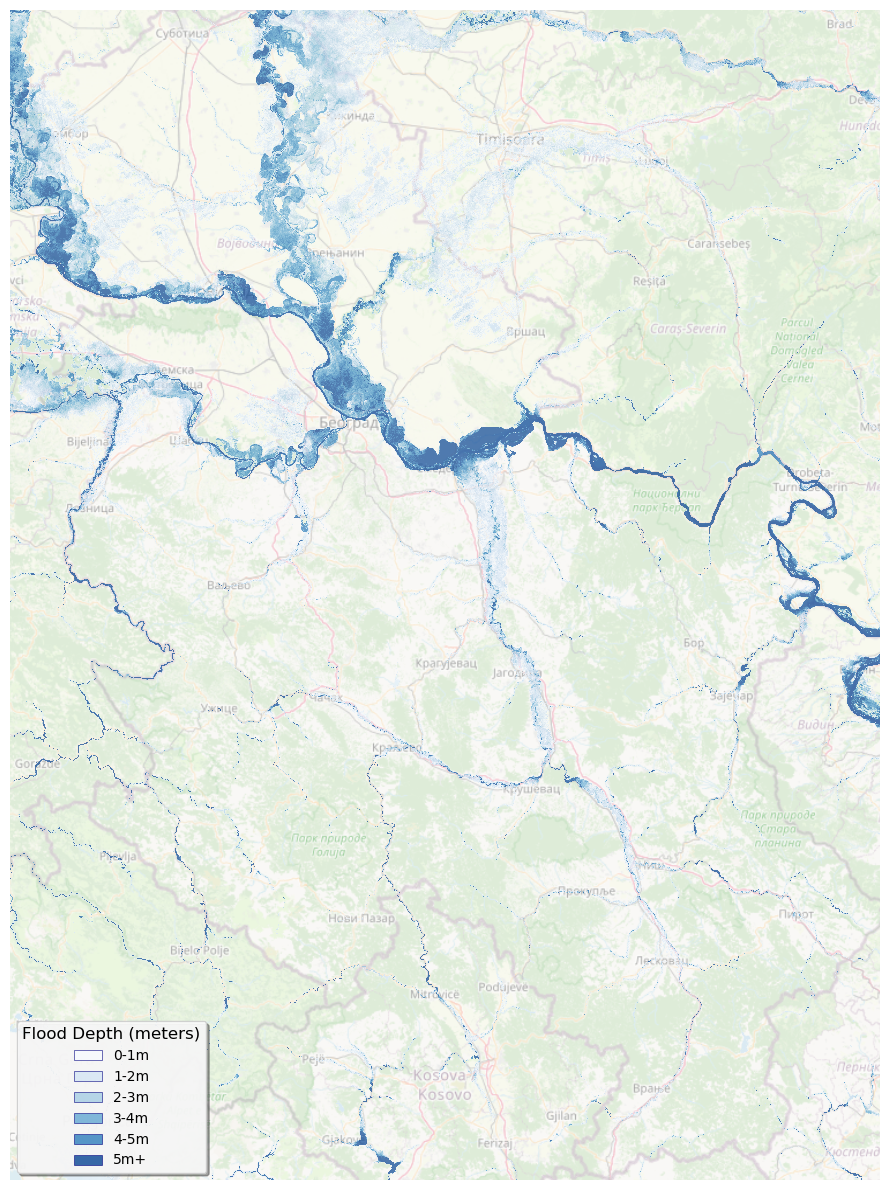

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(9, 12), facecolor='white')

# Blue flood depth colormap
flood_colors = ['#f7fbff', '#deebf7', '#c6dbef', '#9ecae1', '#6baed6', '#4292c6', '#2171b5', '#084594']
flood_cmap = LinearSegmentedColormap.from_list('flood_blue', flood_colors, N=256)

# Reproject to Web Mercator for basemap overlay
if hazard_country.rio.crs is None:
    hazard_country = hazard_country.rio.write_crs("EPSG:4326")
hazard_mercator = hazard_country.rio.reproject("EPSG:3857")

# Plot raster
hazard_mercator.band_data.plot(
    ax=ax, cmap=flood_cmap, alpha=0.7,
    vmin=0, vmax=6,
    add_colorbar=False, add_labels=False,
)

cx.add_basemap(ax=ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.4, attribution=False)
ax.axis('off')

# Legend
flood_labels = ['0-1m', '1-2m', '2-3m', '3-4m', '4-5m', '5m+']
legend_colors = [flood_cmap(i / 5) for i in range(6)]
legend_elements = [Patch(facecolor=legend_colors[i], label=flood_labels[i],
                         edgecolor='navy', linewidth=0.5, alpha=0.8)
                   for i in range(len(flood_labels))]
ax.legend(handles=legend_elements, title='Flood Depth (meters)',
          loc='lower left', fontsize=10, title_fontsize=12,
          frameon=True, fancybox=True, shadow=True, framealpha=0.9,
          facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.show()

## Step 4: Overlay Flood Depth onto Roads

We assign the maximum flood depth from the raster to each road segment using zonal statistics.

In [50]:
roads = assign_flood_depth_to_roads(
    roads=roads,
    raster_data=hazard_country.band_data.values.squeeze(),
    raster_bounds=hazard_country.rio.bounds(),
    raster_crs=hazard_country.rio.crs,
)

# Simplify to flooded / not flooded
roads["flood_class"] = roads["flood_class"].apply(
    lambda x: "No flooding" if x == "No flooding" else "Flooded"
)

print(f"\nFlooded segments: {(roads['flood_class'] == 'Flooded').sum():,}")
print(f"Not flooded: {(roads['flood_class'] == 'No flooding').sum():,}")

Roads with flood depth assigned : 2,213
Roads with no flooding          : 3,277
Flood depth range               : 0.10 – 54.62 m

Flooded segments: 2,213
Not flooded: 3,277


### Visualise raw flood exposure on roads (before correction)

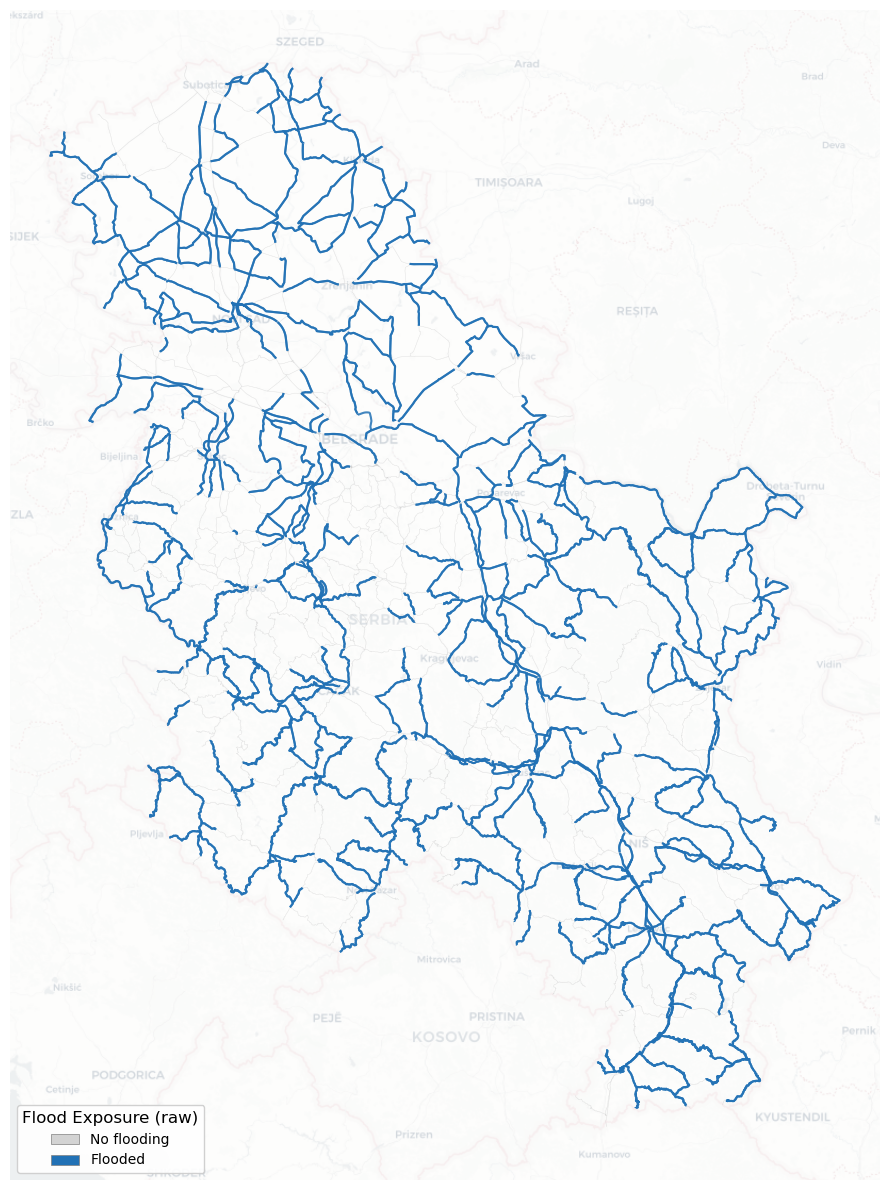

In [51]:
original_crs = roads.crs
roads_plot = roads.to_crs(epsg=3857)

fig, ax = plt.subplots(1, 1, figsize=(9, 12), facecolor="white")

# Not flooded (grey)
roads_plot[roads_plot["flood_class"] == "No flooding"].plot(
    ax=ax, color="#d3d3d3", linewidth=0.3, alpha=0.4, zorder=1
)

# Flooded (blue)
roads_plot[roads_plot["flood_class"] != "No flooding"].plot(
    ax=ax, color="#2171b5", linewidth=1.5, alpha=0.85, zorder=2
)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, alpha=0.4, attribution=False)
ax.axis("off")

legend_handles = [
    Patch(facecolor="#d3d3d3", label="No flooding", edgecolor="grey", linewidth=0.5),
    Patch(facecolor="#2171b5", label="Flooded", edgecolor="grey", linewidth=0.5),
]
ax.legend(handles=legend_handles, title="Flood Exposure (raw)", loc="lower left",
          fontsize=10, title_fontsize=12, frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

## Step 5: Elevation Bias Correction

### Why correct?

Flood hazard maps report water depth **relative to the terrain surface** (DEM). However, roads - especially highways and major routes - are typically built **above** the surrounding terrain on embankments.

A pre-analysis compared measured road elevations (from Z-coordinates in the Serbian road database) against the DEM and found a consistent **positive bias**: roads sit higher than the DEM suggests.

| Road Category | Elevation Bias (meters) | Description |
|:---|:---|:---|
| **IA** (Motorways) | 4.60 m | Highest - built on large embankments |
| **IM** (Urban motorways) | 3.66 m | Also elevated, urban context |
| **IB** (Express roads) | 0.82 m | Moderate embankment |
| **IIA** (Main roads) | 0.82 m | Moderate embankment |
| **IIB** (Regional roads) | 0.82 m | Moderate embankment |

Without this correction, we would significantly overestimate how many road segments are flooded.

### Fix missing road categories

Some road segments have missing category labels — we fill them based on the road designation code.

In [52]:
cat_map = {
    'A1': 'IA',
    'A2': 'IA',
    'A3': 'IA',
    'A4': 'IA',
    '39': 'IB'
}

mask = roads['kategorija'].isna()
roads.loc[mask, 'kategorija'] = roads.loc[mask, 'oznaka_put'].map(cat_map)

print(f"Fixed {mask.sum()} segments with missing categories")
print(f"Category distribution:\n{roads['kategorija'].value_counts()}")

Fixed 1596 segments with missing categories
Category distribution:
kategorija
IA     2028
IIA    1549
IB     1139
IIB     602
IM      130
Name: count, dtype: int64


### Apply the elevation bias correction

We subtract the category-specific bias from the raw flood depth. Any resulting negative values (meaning the road is higher than the flood) are clipped to zero.

In [53]:
# Pre-computed elevation bias per road category (meters)
elevation_bias = {
    'IA': 4.601,
    'IM': 3.659,
    'IB': 0.82,
    'IIA': 0.82,
    'IIB': 0.82
}

# Apply correction
roads['bias'] = roads['kategorija'].map(elevation_bias)
roads['corrected_flood_depth'] = (roads['flood_depth_max'] - roads['bias']).clip(lower=0)

# Update flood class based on corrected depth
roads['flood_class_corrected'] = np.where(
    roads['corrected_flood_depth'] > 0, "Flooded", "No flooding"
)

# Summary
summary = roads.groupby('kategorija').agg(
    total=('flood_depth_max', 'count'),
    originally_flooded=('flood_depth_max', lambda x: (x > 0).sum()),
    still_flooded=('corrected_flood_depth', lambda x: (x > 0).sum()),
    bias=('bias', 'first'),
    avg_original_depth=('flood_depth_max', 'mean'),
    avg_corrected_depth=('corrected_flood_depth', 'mean')
).reset_index()
summary['removed'] = summary['originally_flooded'] - summary['still_flooded']
summary['pct_removed'] = (summary['removed'] / summary['originally_flooded'] * 100).round(1)

print(summary.to_string(index=False))

kategorija  total  originally_flooded  still_flooded  bias  avg_original_depth  avg_corrected_depth  removed  pct_removed
        IA    594                 594             89 4.601            2.510253             0.335044      505         85.0
        IB    584                 584            555 0.820            5.284839             4.476991       29          5.0
       IIA    759                 759            662 0.820            4.199436             3.422950       97         12.8
       IIB    212                 212            176 0.820            3.518745             2.750623       36         17.0
        IM     52                  52             18 3.659            3.374058             1.034846       34         65.4


## Step 6: Before vs After Correction

Side-by-side comparison showing how many flood-exposed roads are removed after accounting for road elevation.

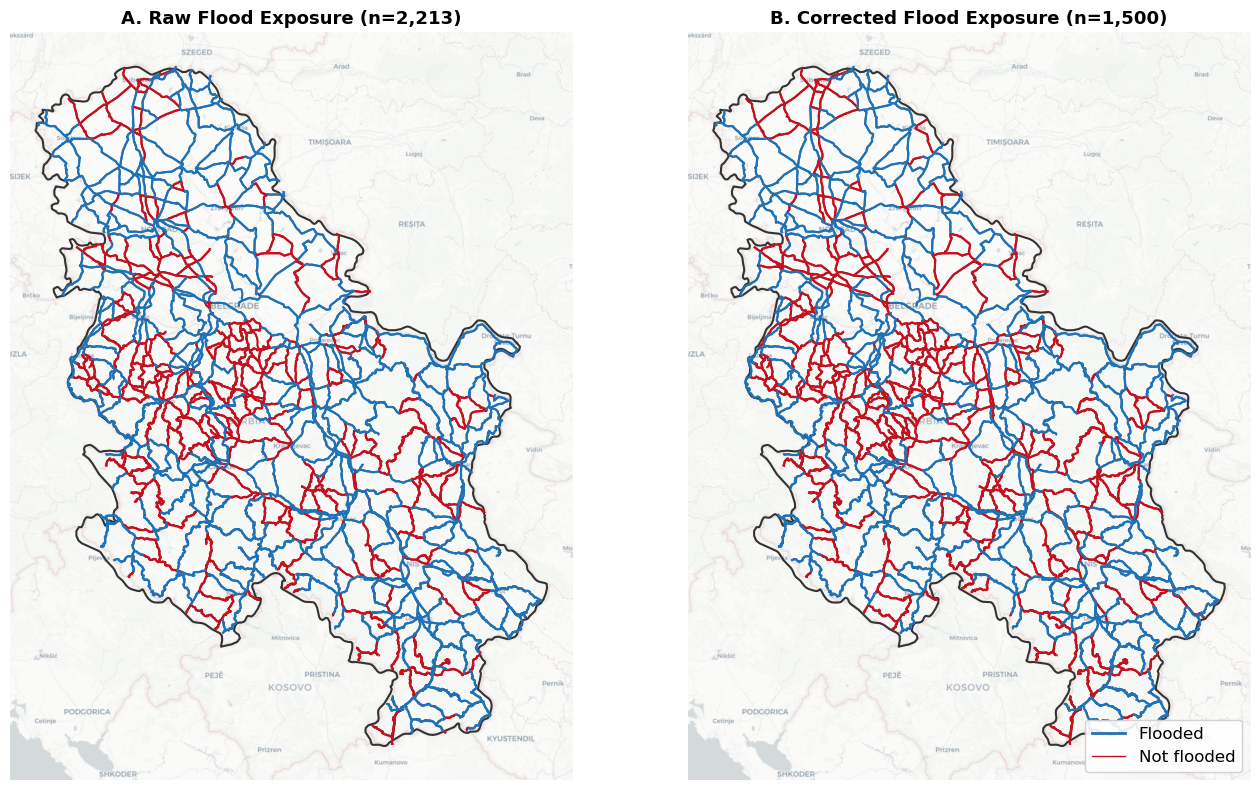


Raw flooded segments:       2,213
Corrected flooded segments: 1,500
Segments removed:           713


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8), facecolor='white')

serbia_mercator = country_plot.to_crs(3857)
roads_mercator = roads.to_crs(3857)

for idx, (label, depth_col, class_col, title) in enumerate([
    ('A', 'flood_depth_max', 'flood_class', 'Raw Flood Exposure'),
    ('B', 'corrected_flood_depth', 'flood_class_corrected', 'Corrected Flood Exposure'),
]):
    ax = axes[idx]

    # Country outline
    serbia_mercator.plot(ax=ax, facecolor='none', edgecolor='#333333',
                         linewidth=1.5, zorder=1)

    # Not flooded (red)
    not_flooded = roads_mercator[roads_mercator[class_col] == "No flooding"]
    if not not_flooded.empty:
        not_flooded.plot(ax=ax, color='#c1121f', linewidth=1.5, zorder=2)

    # Flooded (blue)
    flooded = roads_mercator[roads_mercator[class_col] != "No flooding"]
    if not flooded.empty:
        flooded.plot(ax=ax, color='#2171b5', linewidth=1.5, zorder=3)

    cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, attribution=False)
    ax.set_aspect('equal')
    ax.axis('off')

    # Panel label
    n_flooded = (roads[class_col] != "No flooding").sum()
    ax.set_title(f"{label}. {title} (n={n_flooded:,})", fontsize=13, fontweight='bold')

# Legend
legend_elements = [
    Line2D([0], [0], color='#2171b5', lw=2, label='Flooded'),
    Line2D([0], [0], color='#c1121f', lw=1, label='Not flooded'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=12,
               frameon=True, fancybox=True, framealpha=0.9,
               facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.savefig(figure_path / 'flood_exposure_correction.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nRaw flooded segments:       {(roads['flood_class'] != 'No flooding').sum():,}")
print(f"Corrected flooded segments: {(roads['flood_class_corrected'] != 'No flooding').sum():,}")
print(f"Segments removed:           {(roads['flood_class'] != 'No flooding').sum() - (roads['flood_class_corrected'] != 'No flooding').sum():,}")

## Step 7: Save Results as ArcGIS Layers

The results are saved as:
- **GeoPackage** (.gpkg) — the data, viewable in any GIS software
- **Layer file** (.lyrx) — pre-styled for ArcGIS Pro with correct symbology

After running this cell, open the `.lyrx` file in ArcGIS Pro to see the flood exposure on your map.

In [56]:
save_lyrx_layer(
    gdf=roads.to_crs(original_crs),
    gpkg_path=arcgis_gpkg / "flood_depth_roads.gpkg",
    lyrx_path=arcgis_results / "flood_depth_roads.lyrx",
    layer_name="flood_depth_roads",
    labels=["No flooding", "Flooded"],
    colors=["#d3d3d3", "#2171b5"],
    width_mapping={"No flooding": 0.3, "Flooded": 1.5},
    field="flood_class_corrected",
    title="Flood Depth on Roads (Corrected)",
)

print("\n✅ Done! Open 'flood_depth_roads.lyrx' in ArcGIS Pro to view the results.")

Saved GeoPackage → C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\Geopackages\flood_depth_roads.gpkg
Saved layer file → C:\Users\eks510\OneDrive - Vrije Universiteit Amsterdam\2_Projects\AFD_Serbia\Analysis\criticality_serbia_workshop_day2\results\ArcGIS layers\flood_depth_roads.lyrx

✅ Done! Open 'flood_depth_roads.lyrx' in ArcGIS Pro to view the results.
